# XAI Evaluation — Dataset 1
Quantitative evaluation of **SHAP** and **LIME** across **three models** (RF, SVM, MLP) using:

1. **Correctness**: Incremental Deletion, via AOPC
2. **Consistency**: Jaccard Similarity
3. **Contrastivity**: Local Lipschitz Constants

Each metric is applied identically to all three models

In [107]:
import joblib
import numpy as np
import pandas as pd
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
from sklearn.metrics import f1_score
from scipy.stats import entropy

warnings.filterwarnings('ignore')

X_train_raw   = np.load('../models/ds1/X_train.npy')
X_test_raw    = np.load('../models/ds1/X_test.npy')
y_test        = np.load('../models/ds1/y_test.npy')
feature_names = pd.read_csv('../models/ds1/feature_names.csv').squeeze().tolist()
X_train = pd.DataFrame(X_train_raw, columns=feature_names)
X_test  = pd.DataFrame(X_test_raw,  columns=feature_names)
class_names = ['Healthy', 'Benign', 'Cancer']
n_features  = len(feature_names)
train_means = X_train.mean()   #used for feature masking in Correctness

rf_model  = joblib.load('../models/ds1/ds1_random_forest.pkl')
svm_model = joblib.load('../models/ds1/ds1_svm.pkl')
mlp_model = joblib.load('../models/ds1/ds1_mlp.pkl')
models = {
    'Random Forest': rf_model,
    'SVM':           svm_model,
    'MLP':           mlp_model,
}

os.makedirs('../plots/ds1/evaluation', exist_ok=True)
#118 samples
#11 features
#Classes: {1: 37, 2: 41, 3: 40}

## SHAP values for all models

In [11]:
#random forest
rf_explainer   = shap.TreeExplainer(rf_model)
shap_rf        = rf_explainer.shap_values(X_test)   # list of 3 arrays (n_test, n_feat)

#svm and mlp
background = shap.sample(X_train, 100, random_state=42)

svm_explainer  = shap.KernelExplainer(svm_model.predict_proba, background)
shap_svm       = svm_explainer.shap_values(X_test)
mlp_explainer  = shap.KernelExplainer(mlp_model.predict_proba, background)
shap_mlp       = mlp_explainer.shap_values(X_test)

shap_values_all = {
    'Random Forest': shap_rf,
    'SVM':           shap_svm,
    'MLP':           shap_mlp,
}
print("SHAP values computed for all models.")

  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

SHAP values computed for all models.


## Metric 1 — Correctness: Incremental Deletion

Features are removed one-by-one in **descending order of global SHAP importance** (or LIME importance).  
Removed features are replaced with their training-set mean.  
A good XAI method should produce the **steepest F1 drop** compared to random-order deletion.

- **AOPC** (Area Over the Perturbation Curve): higher AOPC inidcates better correctness.


In [13]:
#Global SHAP importance = mean |SHAP| averaged over classes
def global_shap_importance(shap_vals):
    """shap_vals: list of (n_test, n_feat) arrays, one per class."""
    mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    return np.argsort(mean_abs)[::-1]   # descending

#Global LIME importance 
def global_lime_importance(model_fn, n_runs=30):
    """Average |weight| across a sample of test instances and all classes."""
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=feature_names,
        class_names=class_names, mode='classification', random_state=42)
    importances = np.zeros(n_features)
    indices = np.random.RandomState(0).choice(len(X_test), min(n_runs, len(X_test)), replace=False)
    for idx in indices:
        for cls_idx in range(len(class_names)):
            exp = lime_exp.explain_instance(
                X_test.iloc[idx].values, model_fn,
                num_features=n_features, labels=[cls_idx])
            for feat_idx, weight in exp.local_exp.get(cls_idx, []):
                importances[feat_idx] += abs(weight)
    return np.argsort(importances)[::-1]

#Incremental deletion
def incremental_deletion_f1(model, X, y, feature_order):
    """Return F1 (macro) at each step of removing top-k features."""
    X_masked = X.copy()
    f1_scores = [f1_score(y, model.predict(X_masked), average='macro')]
    for feat_idx in feature_order:
        X_masked = X_masked.copy()
        X_masked.iloc[:, feat_idx] = train_means.iloc[feat_idx]
        f1_scores.append(f1_score(y, model.predict(X_masked), average='macro'))
    return np.array(f1_scores)

def aopc(f1_curve):
    """Area Over Perturbation Curve = mean drop from baseline"""
    return float(np.mean(f1_curve[0] - f1_curve))

print("Correctness helpers defined.")

Correctness helpers defined.


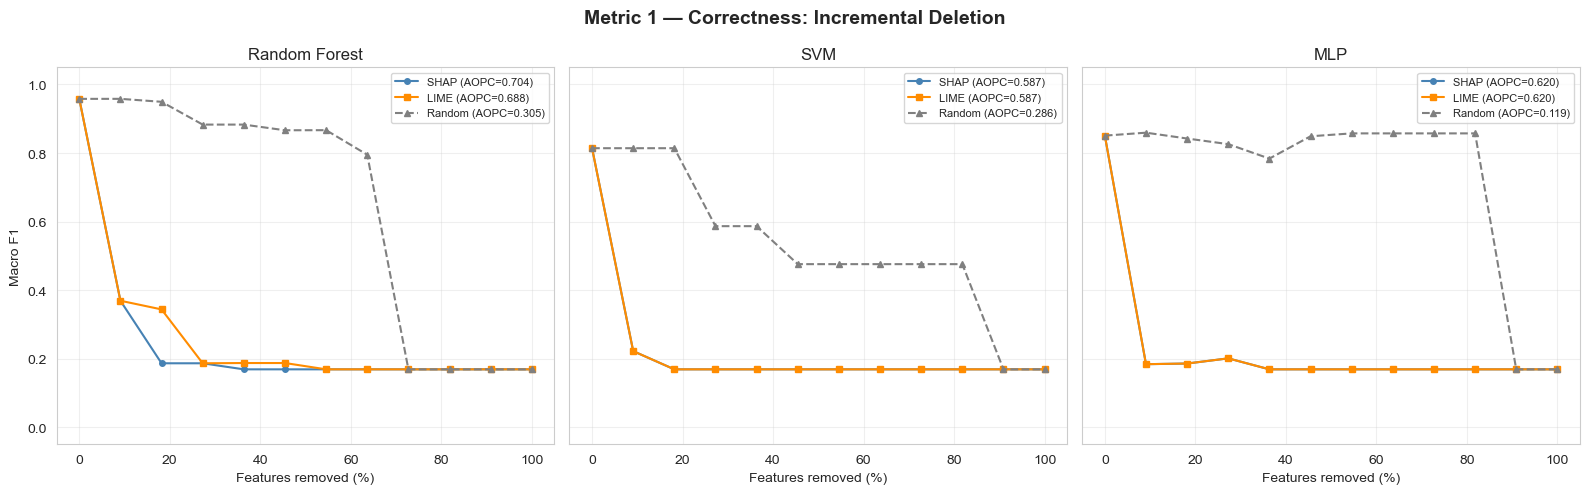

Correctness plots saved.


In [143]:
np.random.seed(42)
correctness_results = {}

x_axis = np.linspace(0, 100, n_features + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Metric 1 — Correctness: Incremental Deletion', fontsize=14, fontweight='bold')

for ax, (model_name, model) in zip(axes, models.items()):
    shap_vals = shap_values_all[model_name]

    order_shap   = global_shap_importance(shap_vals)
    order_lime   = global_lime_importance(model.predict_proba)
    order_random = np.random.permutation(n_features)

    f1_shap   = incremental_deletion_f1(model, X_test, y_test, order_shap)
    f1_lime   = incremental_deletion_f1(model, X_test, y_test, order_lime)
    f1_random = incremental_deletion_f1(model, X_test, y_test, order_random)

    correctness_results[model_name] = {
        'aopc_shap'  : aopc(f1_shap),
        'aopc_lime'  : aopc(f1_lime),
        'aopc_random': aopc(f1_random),
        'f1_shap'    : f1_shap,
        'f1_lime'    : f1_lime,
        'f1_random'  : f1_random,
    }

    ax.plot(x_axis, f1_shap,   marker='o', ms=4, label=f'SHAP (AOPC={aopc(f1_shap):.3f})',   color='steelblue')
    ax.plot(x_axis, f1_lime,   marker='s', ms=4, label=f'LIME (AOPC={aopc(f1_lime):.3f})',   color='darkorange')
    ax.plot(x_axis, f1_random, marker='^', ms=4, label=f'Random (AOPC={aopc(f1_random):.3f})', color='grey', linestyle='--')
    ax.set_title(model_name)
    ax.set_xlabel('Features removed (%)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Macro F1')
plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/ds1_1_correctness_incremental_deletion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correctness plots saved.")


## Metric 2 — Consistency

**2a. SHAP Jaccard Similarity** — TreeExplainer (RF) is exact; KernelExplainer (SVM, MLP) introduces minor sampling variance. We run 5 times and compute mean pairwise Spearman correlation of global importance vectors.

**2b. LIME Jaccard Similarity** — LIME is stochastic. We run 10 times on each test instance and measure how stable the top-5 feature set is across runs.


In [17]:
from scipy.stats import spearmanr

N_RUNS_SHAP = 5
TOP_K       = 5
SHAP_SAMPLE = 30

consistency_results = {}

sample_indices = np.random.RandomState(0).choice(len(X_test), SHAP_SAMPLE, replace=False)

for model_name, model in models.items():
    all_shap_jaccard = []

    for idx in sample_indices:
        run_topk = []
        for seed in range(N_RUNS_SHAP):
            if model_name == 'Random Forest':
                sv = rf_explainer.shap_values(X_test.iloc[[idx]])
            else:
                bg = shap.sample(X_train, 100, random_state=seed)
                sv = shap.KernelExplainer(model.predict_proba, bg).shap_values(X_test.iloc[[idx]])

            imp = np.mean([np.abs(s[0]) for s in sv], axis=0)
            top_feats = set(np.argsort(imp)[::-1][:TOP_K])
            run_topk.append(top_feats)

        for r in range(1, N_RUNS_SHAP):
            inter = len(run_topk[0] & run_topk[r])
            union = len(run_topk[0] | run_topk[r])
            all_shap_jaccard.append(inter / union if union > 0 else 1.0)

    consistency_results[model_name] = {
        'shap_jaccard_mean': float(np.mean(all_shap_jaccard)),
        'shap_jaccard_min':  float(np.min(all_shap_jaccard)),
    }
    print(f"{model_name}: Jaccard mean={np.mean(all_shap_jaccard):.4f}  min={np.min(all_shap_jaccard):.4f}")

print("SHAP consistency (Jaccard) computed.")

Random Forest: Jaccard mean=1.0000  min=1.0000


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

MLP: Jaccard mean=0.9361  min=0.6667
SHAP consistency (Jaccard) computed.


In [19]:
#LIME consistency 
N_RUNS_LIME = 5
TOP_K       = 5
LIME_SAMPLE = 10

lime_base = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=feature_names,
    class_names=class_names, mode='classification')

sample_indices = np.random.RandomState(0).choice(len(X_test), LIME_SAMPLE, replace=False)

for model_name, model in models.items():
    all_jaccard = []
    for idx in sample_indices:
        run_topk = []
        for run in range(N_RUNS_LIME):
            exp = lime_base.explain_instance(
                X_test.iloc[idx].values, model.predict_proba,
                num_features=n_features,
                labels=list(range(len(class_names)))
                #random_state=run - comment it because it takes agesss
            )
            
            top_feats = set()
            for cls_idx in range(len(class_names)):
                ranked = sorted(exp.local_exp.get(cls_idx, []), key=lambda x: -abs(x[1]))
                top_feats.update(f for f, _ in ranked[:TOP_K])
            run_topk.append(top_feats)

        #Jaccard: each run vs run 0
        for r in range(1, N_RUNS_LIME):
            inter = len(run_topk[0] & run_topk[r])
            union = len(run_topk[0] | run_topk[r])
            all_jaccard.append(inter / union if union > 0 else 1.0)

    consistency_results[model_name]['lime_jaccard_mean'] = float(np.mean(all_jaccard))
    consistency_results[model_name]['lime_jaccard_min']  = float(np.min(all_jaccard))

print("LIME consistency computed.")


LIME consistency computed.


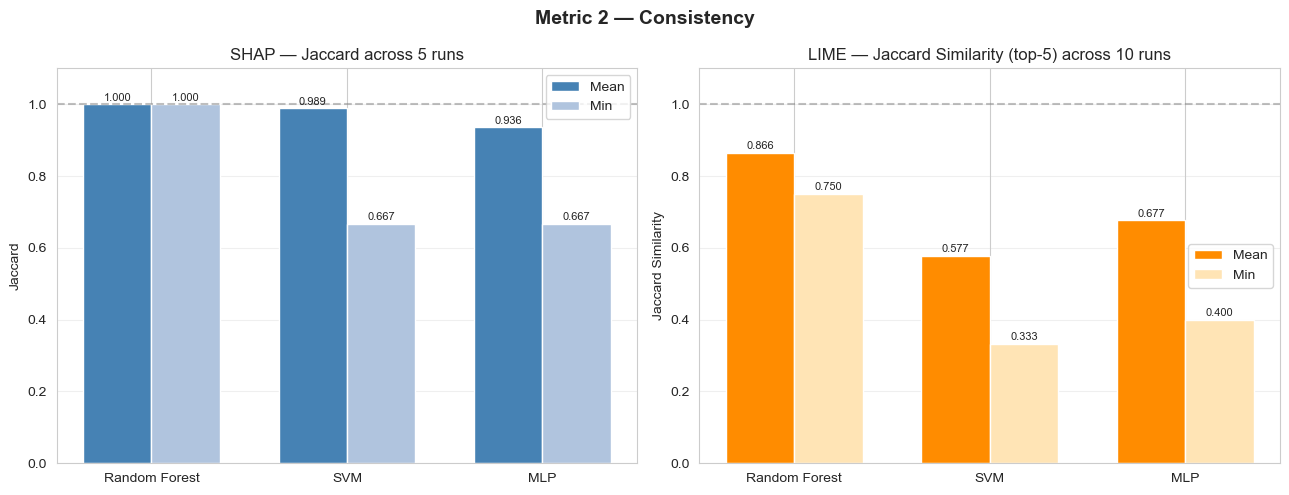

In [145]:
#Plot: Consistency comparison ─────────────────────────────────────────────
model_labels = list(models.keys())
shap_means   = [consistency_results[m]['shap_jaccard_mean'] for m in model_labels]
shap_mins    = [consistency_results[m]['shap_jaccard_min']  for m in model_labels]
lime_means   = [consistency_results[m]['lime_jaccard_mean']  for m in model_labels]
lime_mins    = [consistency_results[m]['lime_jaccard_min']   for m in model_labels]

x = np.arange(len(model_labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Metric 2 — Consistency', fontsize=14, fontweight='bold')

bars1 = ax1.bar(x - width/2, shap_means, width, label='Mean', color='steelblue')
bars2 = ax1.bar(x + width/2, shap_mins,  width, label='Min',  color='lightsteelblue')
ax1.set_title('SHAP — Jaccard across 5 runs')
ax1.set_xticks(x); ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 1.1); ax1.set_ylabel('Jaccard')
ax1.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

bars3 = ax2.bar(x - width/2, lime_means, width, label='Mean', color='darkorange')
bars4 = ax2.bar(x + width/2, lime_mins,  width, label='Min',  color='moccasin')
ax2.set_title(f'LIME — Jaccard Similarity (top-{TOP_K}) across 10 runs')
ax2.set_xticks(x); ax2.set_xticklabels(model_labels)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('Jaccard Similarity')
ax2.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
for bar in bars3: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars4: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/ds1_2_consistency.png', dpi=150, bbox_inches='tight')
plt.show()


## Metric 3 — Contrastivity: Local Lipschitz Constants on LIME and SHAP

- results show low contrastivity
- but very good sensitivity, since perturbation isn't really impacting the results, indicator for robustness

In [25]:
#Contrastivity: Target Sensitivity (Local Lipschitz Constant) 
#Based on Gruensteidl & Kirrane (2025): perturb each instance by 20% Gaussian
#noise, re-explain with SHAP and LIME, compute LLC = ||φ(x) - φ(x')|| / ||x - x'||
#Higher LLC = explanation changes more when input changes = better contrastivity.

from numpy.linalg import norm

PERTURBATION_FRAC = 0.20   #20% noise as in the paper
LLC_SAMPLE        = 20    
N_REPEATS         = 3      #perturbation repeats per instance (paper uses 3)

lime_llc_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=feature_names,
    class_names=class_names, mode='classification', random_state=42)

sample_idx = np.random.RandomState(42).choice(len(X_test), LLC_SAMPLE, replace=False)

# Helper: flatten SHAP explanation for one instance into a single vector
# shap_vals is list of (n_test, n_feat) arrays, one per class
def shap_vector_for_instance(shap_vals_all_classes, instance_idx):
    """Concatenate per-class SHAP values for one instance → 1D vector."""
    return np.concatenate([sv[instance_idx] for sv in shap_vals_all_classes])

# Helper: get LIME explanation vector for one instance (weights across all classes)
def lime_vector_for_instance(model_fn, instance):
    exp = lime_llc_explainer.explain_instance(
        instance, model_fn,
        num_features=n_features,
        labels=list(range(len(class_names)))
    )
    vec = np.zeros(n_features * len(class_names))
    for cls_idx in range(len(class_names)):
        for feat_idx, weight in exp.local_exp.get(cls_idx, []):
            vec[cls_idx * n_features + feat_idx] = weight
    return vec

# Perturbation: add Gaussian noise scaled to 20% of each feature's std
feature_stds = X_train.std().values

contrastivity_llc_results = {}

for model_name, model in models.items():
    shap_vals = shap_values_all[model_name]
    llc_shap_all  = []
    llc_lime_all  = []

    for idx in sample_idx:
        x_orig = X_test.iloc[idx].values.copy()

        # Original explanations
        phi_shap_orig = shap_vector_for_instance(shap_vals, idx)
        phi_lime_orig = lime_vector_for_instance(model.predict_proba, x_orig)

        for _ in range(N_REPEATS):
            # Perturb: Gaussian noise scaled to PERTURBATION_FRAC * feature std
            noise    = np.random.RandomState().randn(n_features) * PERTURBATION_FRAC * feature_stds
            x_pert   = x_orig + noise
            x_pert_df = pd.DataFrame([x_pert], columns=feature_names)

            input_dist = norm(x_orig - x_pert) + 1e-10  # ||x - x'||

            # ── SHAP on perturbed instance ────────────────────────────────────
            if model_name == 'Random Forest':
                sv_pert = rf_explainer.shap_values(x_pert_df)
            else:
                background = shap.sample(X_train, 100, random_state=42)
                sv_pert = shap.KernelExplainer(
                    model.predict_proba, background).shap_values(x_pert_df)

            phi_shap_pert = np.concatenate([sv[0] for sv in sv_pert])
            llc_shap = norm(phi_shap_orig - phi_shap_pert) / input_dist
            llc_shap_all.append(llc_shap)

            # ── LIME on perturbed instance ────────────────────────────────────
            phi_lime_pert = lime_vector_for_instance(model.predict_proba, x_pert)
            llc_lime = norm(phi_lime_orig - phi_lime_pert) / input_dist
            llc_lime_all.append(llc_lime)

    contrastivity_llc_results[model_name] = {
        'shap_llc_mean'   : float(np.mean(llc_shap_all)),
        'shap_llc_median' : float(np.median(llc_shap_all)),
        'shap_llc_all'    : llc_shap_all,
        'lime_llc_mean'   : float(np.mean(llc_lime_all)),
        'lime_llc_median' : float(np.median(llc_lime_all)),
        'lime_llc_all'    : llc_lime_all,
    }
    print(f"{model_name}  |  SHAP LLC mean={np.mean(llc_shap_all):.4f}  "
          f"|  LIME LLC mean={np.mean(llc_lime_all):.4f}")

print("Target Sensitivity (LLC) computed for all models.")

Random Forest  |  SHAP LLC mean=0.0012  |  LIME LLC mean=0.0015


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

MLP  |  SHAP LLC mean=0.0020  |  LIME LLC mean=0.0015
Target Sensitivity (LLC) computed for all models.


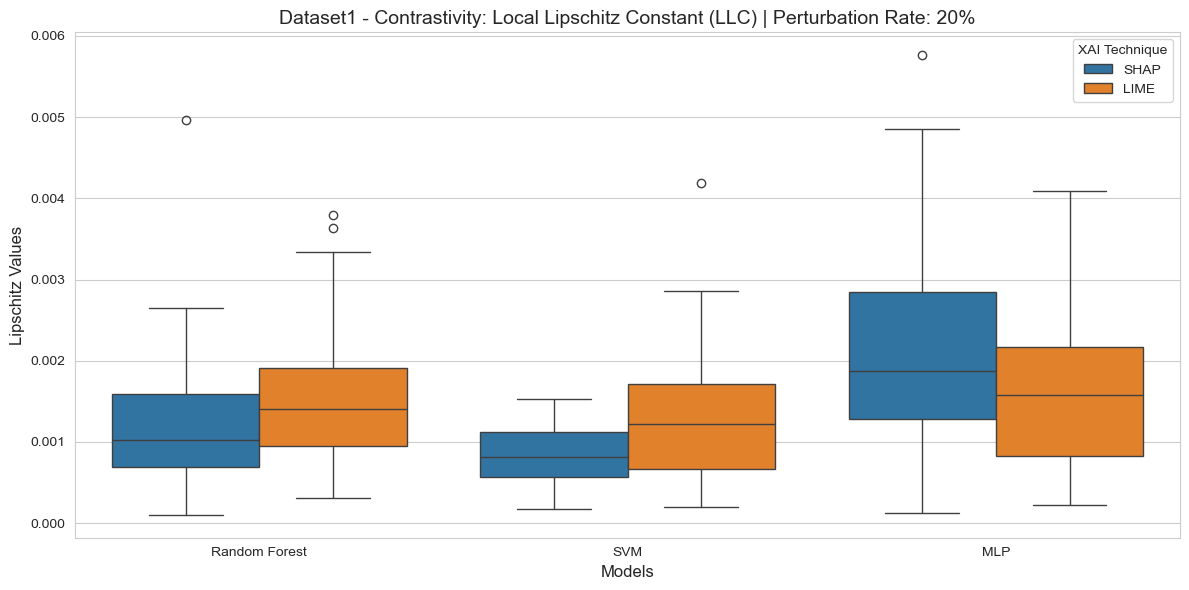

In [141]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = []
for model_name, results in contrastivity_llc_results.items():
    for val in results['shap_llc_all']:
        plot_data.append({'Model': model_name, 'LLC': val, 'Method': 'SHAP'})
    for val in results['lime_llc_all']:
        plot_data.append({'Model': model_name, 'LLC': val, 'Method': 'LIME'})

df_plot = pd.DataFrame(plot_data)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.boxplot(x='Model', y='LLC', hue='Method', data=df_plot, showfliers=True)

plt.title('Dataset1 - Contrastivity: Local Lipschitz Constant (LLC) | Perturbation Rate: 20%', fontsize=14)
plt.ylabel('Lipschitz Values', fontsize=12)
plt.xlabel('Models', fontsize=12)

plt.legend(title='XAI Technique')
plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/ds1_3_contrastivity_llc.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
contrastivity_llc_results

{'Random Forest': {'shap_llc_mean': 0.0011665679939064746,
  'shap_llc_median': 0.0010207661548828953,
  'shap_llc_all': [0.0008964432674764718,
   0.0002525627696393248,
   0.0009079766083567045,
   0.0017115597422450485,
   0.0013020369993827264,
   0.0006834354523790211,
   0.0006068936221498872,
   0.00206974956552034,
   0.0010289254637440254,
   0.0001899794681595314,
   0.00025072247530759774,
   0.00044148677466817455,
   0.0010126068460217655,
   0.00020009193772351546,
   0.00098492810333337,
   0.0022839440100646024,
   0.0023092586568636267,
   0.000869768450577766,
   0.00012781883482448862,
   0.00017801342582413575,
   0.00010330785839822669,
   0.001971749074618818,
   0.002644269557334901,
   0.001878290834359851,
   0.002118823718299433,
   0.0012849944538683962,
   0.0018118692717552242,
   0.0012591662317557038,
   0.0010339614209932887,
   0.001011346851159046,
   0.0016716507435168909,
   0.0014289704580250425,
   0.004967620865225737,
   0.00048120103034204404,
 

## Summary, all models and all metrics

Consolidated table and comparison chart across RF, SVM, and MLP.


In [149]:
rows = []
for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_llc_results[model_name]

    rows.append({
        'Model'                       : model_name,
        # Correctness
        'AOPC SHAP'                   : round(cr['aopc_shap'],   4),
        'AOPC LIME'                   : round(cr['aopc_lime'],   4),
        'AOPC Random (baseline)'      : round(cr['aopc_random'], 4),
        # Consistency
        'SHAP Spearman ρ (mean)'      : round(co['shap_jaccard_mean'], 4),
        'SHAP Spearman ρ (min)'       : round(co['shap_jaccard_min'],  4),
        'LIME Jaccard (mean)'         : round(co['lime_jaccard_mean'],  4),
        'LIME Jaccard (min)'          : round(co['lime_jaccard_min'],   4),
        # Contrastivity
        'SHAP LLC (mean)'             : round(np.mean(ct['shap_llc_all']), 4),
        'LIME LLC (mean)'             : round(np.mean(ct['lime_llc_all']), 4),
        'SHAP LLC (max)'              : round(np.max(ct['shap_llc_all']), 4) # Max shows peak sensitivity
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.head())
summary_df.to_csv('../plots/ds1/evaluation/ds1_xai_eval_summary_table.csv')

               AOPC SHAP  AOPC LIME  AOPC Random (baseline)  \
Model                                                         
Random Forest     0.7038     0.6877                  0.3051   
SVM               0.5871     0.5871                  0.2864   
MLP               0.6198     0.6198                  0.1193   

               SHAP Spearman ρ (mean)  SHAP Spearman ρ (min)  \
Model                                                          
Random Forest                  1.0000                 1.0000   
SVM                            0.9889                 0.6667   
MLP                            0.9361                 0.6667   

               LIME Jaccard (mean)  LIME Jaccard (min)  SHAP LLC (mean)  \
Model                                                                     
Random Forest               0.8656              0.7500           0.0012   
SVM                         0.5774              0.3333           0.0008   
MLP                         0.6767              0.4000         

In [133]:
for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_llc_results[model_name]

    print(f"\n  {model_name}")
    print(f"  {'='*55}")
    print(f"  CORRECTNESS    AOPC-SHAP  = {cr['aopc_shap']:.4f}")
    print(f"                 AOPC-LIME  = {cr['aopc_lime']:.4f}")
    print(f"                 AOPC-RND   = {cr['aopc_random']:.4f}  (baseline)")
    print(f"  {'='*55}")
    print(f"  CONSISTENCY    SHAP ρ     = {co['shap_jaccard_mean']:.4f}  (min {co['shap_jaccard_min']:.4f})")
    print(f"                 LIME J     = {co['lime_jaccard_mean']:.4f}  (min {co['lime_jaccard_min']:.4f})")
    print(f"  {'='*55}")
    #print(f"  CONTRASTIVITY (Target Sensitivity LLC)")
    print(f"  CONTRASTIVITY  SHAP LLC   = {np.mean(ct['shap_llc_all']):.4f}")
    print(f"                 LIME LLC   = {np.mean(ct['lime_llc_all']):.4f}")


  Random Forest
  CORRECTNESS    AOPC-SHAP  = 0.7038
                 AOPC-LIME  = 0.6877
                 AOPC-RND   = 0.3051  (baseline)
  CONSISTENCY    SHAP ρ     = 1.0000  (min 1.0000)
                 LIME J     = 0.8656  (min 0.7500)
  CONTRASTIVITY  SHAP LLC   = 0.0012
                 LIME LLC   = 0.0015

  SVM
  CORRECTNESS    AOPC-SHAP  = 0.5871
                 AOPC-LIME  = 0.5871
                 AOPC-RND   = 0.2864  (baseline)
  CONSISTENCY    SHAP ρ     = 0.9889  (min 0.6667)
                 LIME J     = 0.5774  (min 0.3333)
  CONTRASTIVITY  SHAP LLC   = 0.0008
                 LIME LLC   = 0.0013

  MLP
  CORRECTNESS    AOPC-SHAP  = 0.6198
                 AOPC-LIME  = 0.6198
                 AOPC-RND   = 0.1193  (baseline)
  CONSISTENCY    SHAP ρ     = 0.9361  (min 0.6667)
                 LIME J     = 0.6767  (min 0.4000)
  CONTRASTIVITY  SHAP LLC   = 0.0020
                 LIME LLC   = 0.0015
